## Regression Trees

### Introduction

The dataset used in this exercise session is a subset of the publicly available <a><href='https://www1.nyc.gov/site/tlc/about/tlc-trip-record-data.page'>TLC Dataset</a> (all rights reserved by Taxi & Limousine Commission (TLC), City of New York). 

The prediction of the tip amount can be modeled as a regression problem. 

To train the model you can use part of the input dataset and the remaining data can be used to assess the quality of the trained model.

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

### EDA 

In [2]:
# read the input data
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv'
raw_data = pd.read_csv(url)
raw_data

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41197,2,1,16.94,2,1,132,164,1,70.0,0.5,6.94,1,5.00
41198,2,4,19.83,2,1,132,166,1,70.0,0.5,6.94,1,8.00
41199,2,1,17.31,2,1,132,137,1,70.0,0.5,6.94,1,8.00
41200,2,1,17.28,2,1,132,233,1,70.0,0.5,6.94,1,16.19


In [3]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


Tip amount will be the target variable for us. Therefore, we need to understand the correlation between feature columns aganist target variable.

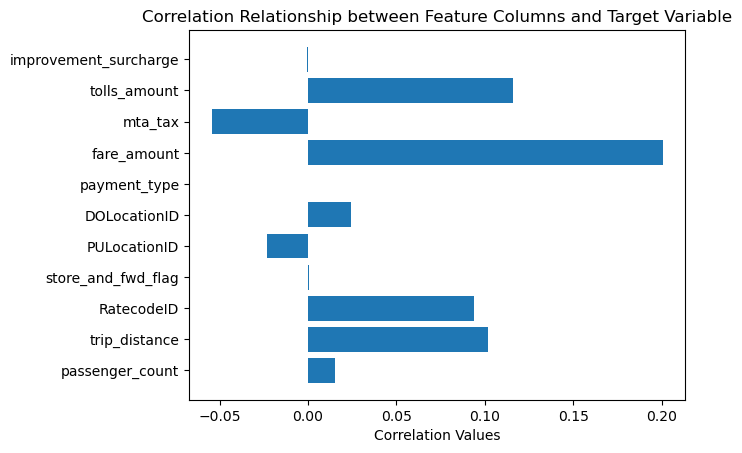

In [4]:
# Clustering the Correlation Values aganist Target Variable
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')

# Showing in Figure
plt.barh(correlation_values.index,correlation_values)
plt.xlabel('Correlation Values')
plt.title('Correlation Relationship between Feature Columns and Target Variable')
plt.show()

This shows us that the input features `payment_type`, `VendorID`, `store_and_fwd_flag` and `improvement_surcharge` have little to no correlation with the target variable.


In [5]:
columns_to_drop = raw_data[['payment_type','VendorID','store_and_fwd_flag','improvement_surcharge']]

raw_data = raw_data.drop(columns_to_drop,axis=1)


### Pre-Processing

In [6]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   passenger_count  41202 non-null  int64  
 1   trip_distance    41202 non-null  float64
 2   RatecodeID       41202 non-null  int64  
 3   PULocationID     41202 non-null  int64  
 4   DOLocationID     41202 non-null  int64  
 5   fare_amount      41202 non-null  float64
 6   mta_tax          41202 non-null  float64
 7   tolls_amount     41202 non-null  float64
 8   tip_amount       41202 non-null  float64
dtypes: float64(5), int64(4)
memory usage: 2.8 MB


In [7]:
raw_data.describe()

,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,fare_amount,mta_tax,tolls_amount,tip_amount
count,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,1.633926,18.384928,2.025411,132.220475,164.546333,69.986150,0.491020,5.608198,14.107666
std,0.924250,2.856605,0.461587,7.726159,67.901529,6.184851,0.066404,2.979348,5.030619
min,1.000000,0.000000,1.000000,10.000000,3.000000,3.700000,0.000000,0.000000,0.010000
25%,1.000000,17.370000,2.000000,132.000000,113.000000,70.000000,0.500000,6.940000,10.000000
50%,1.000000,18.180000,2.000000,132.000000,163.000000,70.000000,0.500000,6.940000,16.190000
75%,2.000000,19.380000,2.000000,132.000000,231.000000,70.000000,0.500000,6.940000,16.190000
max,8.000000,189.910000,5.000000,264.000000,265.000000,199.700000,0.500000,57.000000,98.000000


In [18]:
X = raw_data.drop(['tip_amount'],axis=1)

X = normalize(X, axis=1, norm='l1', copy=False)

y = raw_data['tip_amount']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Build a Decision Tree Regressor model

Regression Trees are implemented using `DecisionTreeRegressor`.

The important parameters of the model are:

`criterion`: The function used to measure error, we use 'squared_error'.

`max_depth` - The maximum depth the tree is allowed to take; we use 8.

In [20]:
# import the Decision Tree Regression Model from scikit-learn
from sklearn.tree import DecisionTreeRegressor

# call the model
model = DecisionTreeRegressor(criterion='squared_error',max_depth=8,random_state=35)

# Fit the model
model.fit(X_train,y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,35
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Evaluate the Scikit-Learn and Snap ML Decision Tree Regressor Models

In [21]:
# run inference using the sklearn model
prediction = model.predict(X_test)

# evaluate mean squared error on the test dataset
mse_score = mean_squared_error(y_test, prediction)
print('MSE score : {0:.3f}'.format(mse_score))

r2_score = model.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 24.287
R^2 score : 0.021


### Variations

What if we change the max_depth to 12? How would the $MSE$ and $R^2$ be affected? 

In [22]:
# call the model
model = DecisionTreeRegressor(criterion='squared_error',max_depth=12,random_state=35)

# Fit the model
model.fit(X_train,y_train)

# run inference using the sklearn model
prediction = model.predict(X_test)

# evaluate mean squared error on the test dataset
mse_score = mean_squared_error(y_test, prediction)
print('MSE score : {0:.3f}'.format(mse_score))

r2_score = model.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 25.859
R^2 score : -0.042


Identify the top 3 features with the most effect on the `tip_amount`.

In [33]:
correlation_values = raw_data.corr()['tip_amount'].drop('tip_amount')

correlation_values.sort_values(ascending=False).head(3)

fare_amount      0.200638
tolls_amount     0.116172
trip_distance    0.101819
Name: tip_amount, dtype: float64